### Introduction 
Les PINNs est un reseau de neurones qui utilise la physique pour apprendre avec moins de données, permet de resoudre les equations physiques


# Équation de diffusion 1D (équation de la chaleur)

Nous résolvons numériquement l'équation de la chaleur en dimension 1 :

$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}
$$

où :

- $u(t,x)$ : température
- $t$ : temps
- $x$ : position dans la barre
- $\alpha$ : diffusivité thermique

La diffusivité thermique est donnée par :

$$
\alpha = \frac{K}{\rho C_p}
$$

avec :

- $K$ : conductivité thermique
- $\rho$ : masse volumique
- $C_p$ : capacité thermique massique

---

# Domaine du problème

On considère :

$$
x \in [0,L], \quad t \in [0,T_f]
$$

avec :

- $L = 1$
- $T_f = 1$

---

# Conditions aux limites

Les conditions aux limites sont de type **Dirichlet homogène** :

$$
u(t,0) = 0
$$

$$
u(t,L) = 0
$$

pour tout $t > 0$.

---

# Condition initiale

La température initiale est donnée par :

$$
u(0,x) = \sin(\pi x)
$$

---

# Discrétisation numérique

L'équation est résolue par un **schéma implicite en temps** (Euler implicite) et une **discrétisation en différences finies en espace**.

Le schéma utilisé est :

$$
\frac{u_i^{n+1} - u_i^n}{\Delta t}
=
\alpha
\frac{u_{i+1}^{n+1} - 2u_i^{n+1} + u_{i-1}^{n+1}}{\Delta x^2}
$$

Ce schéma conduit à la résolution à chaque pas de temps du système linéaire :

$$
A U^{n+1} = U^n
$$

où la matrice $A$ est tridiagonale.

---

# Solution analytique

Pour ce problème particulier, la solution exacte est connue :

$$
u(t,x) = e^{-\alpha \pi^2 t} \sin(\pi x)
$$



In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# ---------------------------------------------------------
# Paramètres physiques
# ---------------------------------------------------------
alpha = 0.3

# ---------------------------------------------------------
# Données du problème
# ---------------------------------------------------------
L = 1.0
Tf = 1.0
N = 10000
ht = Tf / N

u0 = lambda x: np.sin(np.pi * x)

# ---------------------------------------------------------
# Étude de convergence en fonction de J
# ---------------------------------------------------------
TJ = np.round(np.logspace(1, 2, 10)).astype(int)
err = []

for J in TJ:
    x = np.linspace(0, L, J+1)
    x_inner = x[1:-1]
    hx = L / J

    # Matrice du schéma implicite
    main_diag = (1 + 2*alpha*ht/hx**2) * np.ones(J-1)
    off_diag  = (-alpha*ht/hx**2) * np.ones(J-2)
    A = diags([off_diag, main_diag, off_diag], [-1,0,1]).tocsc()

    # ---------------------------------------------------------
    # U[n, i] : n = temps, i = espace
    # ---------------------------------------------------------
    U = np.zeros((N+1, J+1))

    # Condition initiale : t=0
    U[0, 1:J] = u0(x_inner)

    # Boucle en temps
    for n in range(N):
        b = U[n, 1:J]          # solution au temps t_n
        U[n+1, 1:J] = spsolve(A, b)

    # Solution finale au temps Tf
    U_num = U[-1, 1:J]


# Résolution de l'équation de la chaleur avec un PINN

Nous utilisons un **Physics-Informed Neural Network (PINN)** pour résoudre l'équation de la chaleur en dimension 1.

---


# Conditions aux limites

Les conditions aux limites sont :

$$
u(t,0) = 0
$$

$$
u(t,1) = 0
$$

Dans le PINN, elles sont imposées directement dans la forme de la solution :

$$
u(t,x) = x(1-x)N(t,x)
$$

où $N(t,x)$ est la sortie du réseau de neurones.

Cette construction garantit automatiquement :

$$
u(t,0)=u(t,1)=0
$$

---
# Résidu de l'équation différentielle

Le réseau doit satisfaire l'équation physique.  
On définit donc le **résidu de l'équation** :

$$
f(t,x) = u_t - \alpha u_{xx}
$$

Les dérivées sont calculées grâce à **l'autodifférentiation**.

---

# Loss physique

Le résidu doit être nul dans le domaine.  
La loss associée est :

$$
\mathcal{L}_{PDE} =
\frac{1}{N_f}
\sum_{i=1}^{N_f}
\left| f(t_f^i,x_f^i) \right|^2
$$

Les points $(t_f^i,x_f^i)$ sont appelés **points de collocation**.
ici choisi de manière aléatoire
---

# Loss condition initiale

La condition initiale est imposée par :

$$
\mathcal{L}_{IC} =
\frac{1}{N_0}
\sum_{i=1}^{N_0}
\left| u(0,x_0^i) - \sin(\pi x_0^i) \right|^2
$$

---

# Fonction de perte totale

La loss totale utilisée pour entraîner le PINN est :

$$
\mathcal{L} = \mathcal{L}_{IC} + \lambda \mathcal{L}_{PDE}
$$

où $\lambda$ est un paramètre qui équilibre les deux contributions.

Le réseau apprend ainsi à satisfaire **simultanément** :

- les conditions initiales
- l'équation différentielle
- les conditions aux limites

In [7]:
import torch
import torch.nn as nn
from torch.autograd import grad
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator

# Condition initiale cohérente avec FD
def f_t(x):
    return torch.sin(torch.pi*x)

In [8]:
class PINN_heat(nn.Module):
    def __init__(self, layers, activations):
        super().__init__()
        
        if len(activations) != len(layers) - 2:
            raise ValueError("The number of activation functions must match the number of hidden layers.")

        self.layers = nn.Sequential()
        for i in range(len(layers) - 1):
            self.layers.add_module(f"linear_{i}", nn.Linear(layers[i], layers[i + 1]))
            if i < len(layers) - 2:
                self.layers.add_module(f"activation_{i}", activations[i])

    def forward(self, t, x):
        inputs = torch.hstack((t, x))
        N = self.layers(inputs)
        f = torch.sin(np.pi * x)  # IC
        return f + t * x * (1 - x) * N

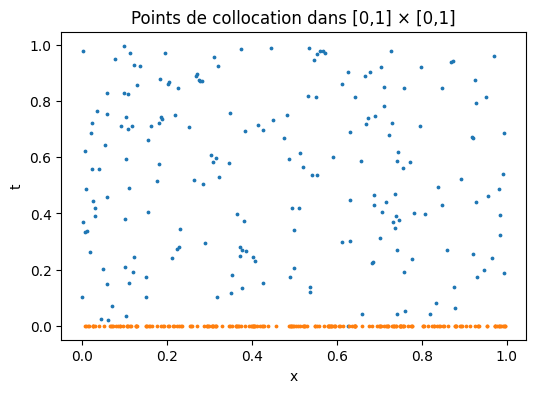

In [9]:
import matplotlib.pyplot as plt
batch_size=200
t_tmp = torch.rand((batch_size,1)).requires_grad_()
x_tmp = torch.rand((batch_size,1)).requires_grad_()
plt.figure(figsize=(6,4))
plt.scatter(x_tmp.detach(), t_tmp.detach(), s=3)
# t=0 (initial condition)
plt.scatter(torch.rand(batch_size,1), torch.zeros(batch_size,1), s=3, label="Initial")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Points de collocation dans [0,1] × [0,1]")
plt.savefig("point_de_collocation", dpi=300, bbox_inches='tight')

plt.show()


In [10]:
def train_heat(model, optimizer, alpha, batch_size=128, epochs=1000):
     # Création du scheduler ici
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=3000, gamma=0.5)
    for epoch in range(epochs):

        # 1) Points de collocation (intérieur)
        # t_f = torch.rand((batch_size,1)).requires_grad_()
        # x_f = torch.rand((batch_size,1)).requires_grad_()
        t1 = torch.rand((batch_size//2,1))          # uniforme
        t2 = 0.5 + 0.5*torch.rand((batch_size//2,1)) # t ∈ [0.5,1]
        t_f = torch.vstack([t1, t2]).requires_grad_()

        x1 = torch.rand((batch_size//2,1))
        x2 = 0.25 + 0.5*torch.rand((batch_size//2,1))  # x ∈ [0.25,0.75]
        x_f = torch.vstack([x1, x2]).requires_grad_()

        
        optimizer.zero_grad()
        
        # PDE loss
        u = model(t_f, x_f)
        u_t = grad(u, t_f, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_x = grad(u, x_f, grad_outputs=torch.ones_like(u), create_graph=True)[0]
        u_xx = grad(u_x, x_f, grad_outputs=torch.ones_like(u_x), create_graph=True)[0]
        residual = u_t - alpha * u_xx
        loss_pde = residual.square().mean()

        

        # Total loss
        loss = loss_pde

        loss.backward()
        optimizer.step()
        scheduler.step()

    
        if epoch % 1000 == 0:
           print(f"Epoch {epoch}, "
          f"loss_total={loss.item():.3e} "
         )




In [11]:
learning_rate = 0.001
epochs = 10000
batch_size = 128

layers = [2, 64, 64, 64, 1]
activations = [nn.Tanh(), nn.Tanh(), nn.Tanh()]

model_heat_d = PINN_heat(layers, activations)
optimizer_heat_d = torch.optim.Adam(model_heat_d.parameters(), lr=learning_rate)

train_heat(model_heat_d, optimizer_heat_d, alpha, batch_size, epochs)


Epoch 0, loss_total=6.091e+00 
Epoch 1000, loss_total=1.463e-03 
Epoch 2000, loss_total=2.752e-04 
Epoch 3000, loss_total=7.454e-05 
Epoch 4000, loss_total=1.978e-05 
Epoch 5000, loss_total=1.513e-05 
Epoch 6000, loss_total=3.246e-05 
Epoch 7000, loss_total=6.631e-06 
Epoch 8000, loss_total=9.633e-06 
Epoch 9000, loss_total=3.279e-05 


In [12]:
# Grille pour t et x
t = np.linspace(0, Tf , 100)
x = np.linspace(0, 1, 100)
tt, xx = np.meshgrid(t, x)

# Conversion en tenseurs
tt_plot = torch.tensor(tt, dtype=torch.float32).reshape(-1,1)
xx_plot = torch.tensor(xx, dtype=torch.float32).reshape(-1,1)

# Évaluation du PINN
with torch.no_grad():
    u = model_heat_d(tt_plot, xx_plot)

u = u.numpy().reshape(100, 100)



In [13]:
# Grille FD
t_fd = np.linspace(0, Tf, U.shape[0])   # 10001 points → temps
x_fd = np.linspace(0, 1, U.shape[1])    # 101 points → espace

interp_fd = RegularGridInterpolator((t_fd, x_fd), U)
pts = np.vstack([tt.ravel(), xx.ravel()]).T
U_interp = interp_fd(pts).reshape(100, 100)



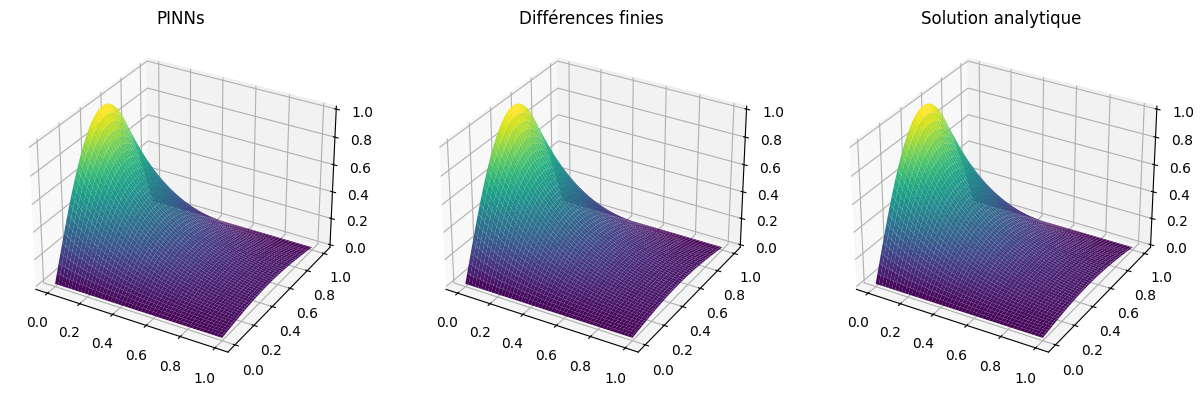

In [14]:
# Solution analytique
u_exact = np.sin(np.pi * xx) * np.exp(-np.pi**2 * alpha * tt)

fig = plt.figure(figsize=(15, 5))

# PINN
ax = fig.add_subplot(131, projection='3d')
ax.plot_surface(tt, xx, u, cmap='viridis')
ax.set_title("PINNs")

# Différences finies interpolées
ax = fig.add_subplot(132, projection='3d')
ax.plot_surface(tt, xx, U_interp, cmap='viridis')

ax.set_title("Différences finies")

# Solution analytique
ax = fig.add_subplot(133, projection='3d')
ax.plot_surface(tt, xx, u_exact, cmap='viridis')
ax.set_title("Solution analytique")
plt.savefig("comparaison_PINN_DF_analytique.png", dpi=300, bbox_inches='tight')
plt.show()


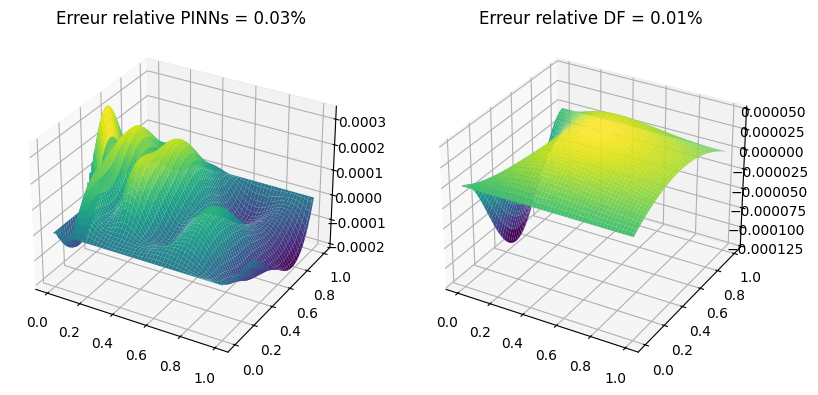

In [15]:
# Erreur
fig = plt.figure(figsize=(15, 5))
ax = fig.add_subplot(131, projection='3d')
ax.plot_surface(tt, xx, u - u_exact, cmap='viridis')
err = np.max(np.abs(u - u_exact)) / np.max(np.abs(u_exact)) * 100
ax.set_title(f"Erreur relative PINNs = {err:.2f}%")

ax = fig.add_subplot(132, projection='3d')
ax.plot_surface(tt, xx, U_interp - u_exact, cmap='viridis')
err = np.max(np.abs(U_interp - u_exact)) / np.max(np.abs(u_exact)) * 100
ax.set_title(f"Erreur relative DF = {err:.2f}%")
plt.show()

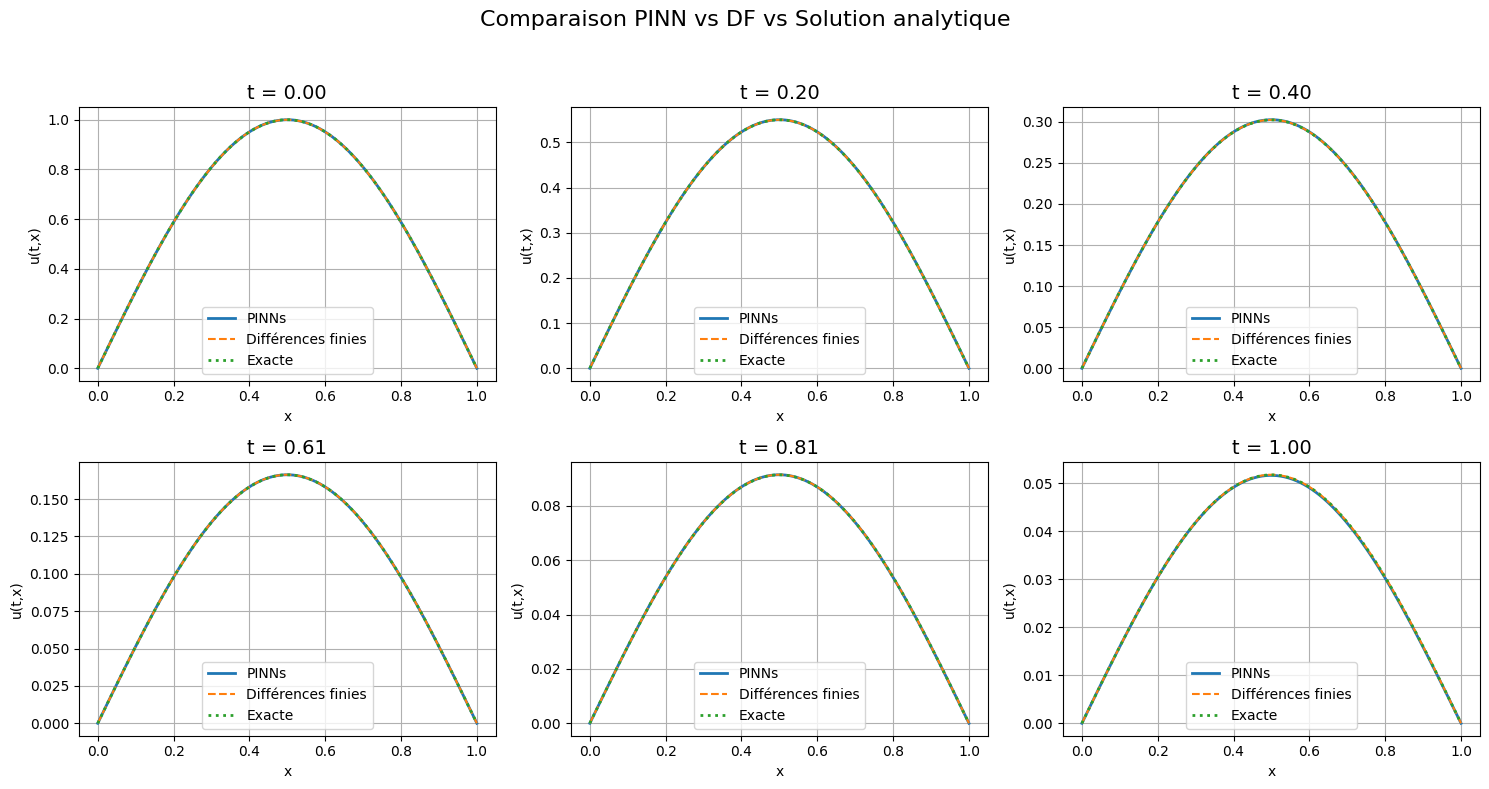

In [16]:
# Define the times to plot the solution
idx_t = [0, 20, 40, 60, 80,  99]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, idx in enumerate(idx_t):

    # Coupes en x au temps t[idx]
    u_slice = u[:, idx]            # PINN
    U_slice = U_interp[:, idx]     # DF
    exact_slice = u_exact[:, idx]  # analytique

    axes[i].plot(x, u_slice, label='PINNs', linewidth=2)
    axes[i].plot(x, U_slice, label='Différences finies', linestyle='--')
    axes[i].plot(x, exact_slice, label='Exacte', linestyle='dotted', linewidth=2)

    axes[i].set_title(f"t = {t[idx]:.2f}", fontsize=14)
    axes[i].set_xlabel("x")
    axes[i].set_ylabel("u(t,x)")
    axes[i].grid(True)
    axes[i].legend()

plt.suptitle("Comparaison PINN vs DF vs Solution analytique", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("comparaison_PINN_DF_analytique2.png", dpi=300, bbox_inches='tight')

plt.show()



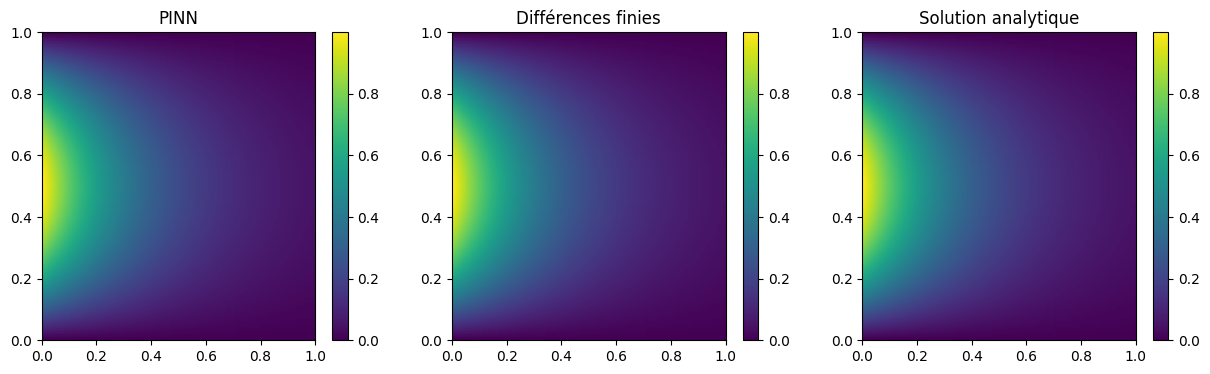

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

im0 = ax[0].imshow(u, extent=[0,1,0,1], origin='lower', aspect='auto', cmap='viridis')
ax[0].set_title("PINN")
plt.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(U_interp, extent=[0,1,0,1], origin='lower', aspect='auto', cmap='viridis')
ax[1].set_title("Différences finies")
plt.colorbar(im1, ax=ax[1])

im2 = ax[2].imshow(u_exact, extent=[0,1,0,1], origin='lower', aspect='auto', cmap='viridis')
ax[2].set_title("Solution analytique")
plt.colorbar(im2, ax=ax[2])
plt.savefig("comparaison_PINN_DF_analytique3.png", dpi=300, bbox_inches='tight')

plt.show()


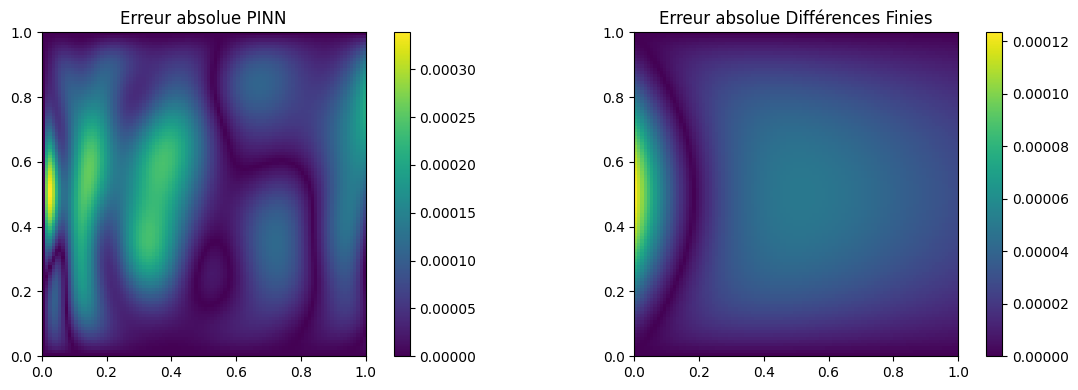

In [18]:
import numpy as np
import matplotlib.pyplot as plt

# --- Calcul des erreurs absolues ---
err_pinn = np.abs(u - u_exact)
err_fd   = np.abs(U_interp - u_exact)

# --- Affichage ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Erreur PINN
im0 = ax[0].imshow(err_pinn, extent=[0,1,0,1], origin='lower', cmap='viridis')
ax[0].set_title("Erreur absolue PINN")
plt.colorbar(im0, ax=ax[0])

# Erreur DF
im1 = ax[1].imshow(err_fd, extent=[0,1,0,1], origin='lower', cmap='viridis')
ax[1].set_title("Erreur absolue Différences Finies")
plt.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.savefig("comparaison_PINN_DF_Erreurs.png", dpi=300, bbox_inches='tight')

plt.show()


In [19]:
rel_L2_pinn = np.linalg.norm(u - u_exact) / np.linalg.norm(u_exact)
rel_L2_fd   = np.linalg.norm(U_interp - u_exact) / np.linalg.norm(u_exact)

print("Erreur relative L2 PINN :", rel_L2_pinn)
print("Erreur relative L2 DF   :", rel_L2_fd)


Erreur relative L2 PINN : 0.00034943152611836397
Erreur relative L2 DF   : 0.00011139447316948673


C:\Users\fatol\AppData\Local\Temp\ipykernel_7016\279490544.py:8: RuntimeWarning: invalid value encountered in divide
  err_rel_fd   = np.abs(U_interp - u_exact) / (np.abs(u_exact) )


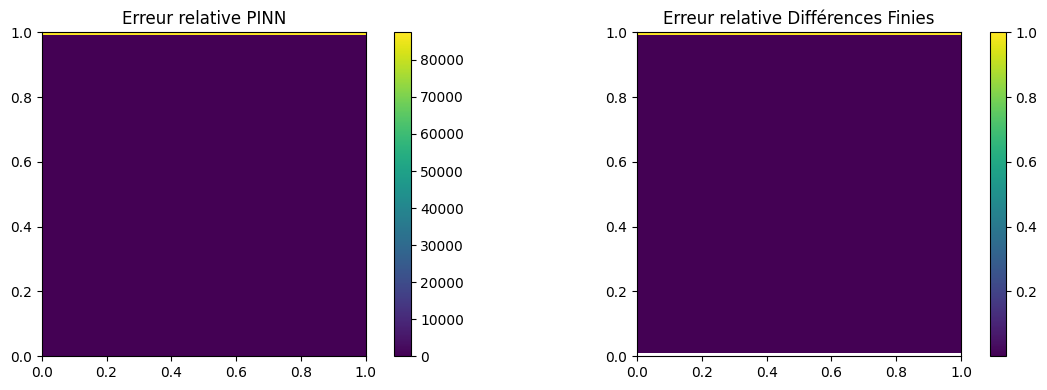

In [21]:
import numpy as np
import matplotlib.pyplot as plt

eps = 1e-12  # pour éviter la division par zéro

# --- Calcul des erreurs relatives ---
err_rel_pinn = np.abs(u - u_exact) / (np.abs(u_exact) + eps)
err_rel_fd   = np.abs(U_interp - u_exact) / (np.abs(u_exact) )

# --- Affichage ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Erreur relative PINN
im0 = ax[0].imshow(err_rel_pinn, extent=[0,1,0,1], origin='lower', cmap='viridis')
ax[0].set_title("Erreur relative PINN")
plt.colorbar(im0, ax=ax[0])

# Erreur relative DF
im1 = ax[1].imshow(err_rel_fd, extent=[0,1,0,1], origin='lower', cmap='viridis')
ax[1].set_title("Erreur relative Différences Finies")
plt.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.savefig("comparaison_PINN_DF_Erreurs_Relatives.png", dpi=300, bbox_inches='tight')
plt.show()


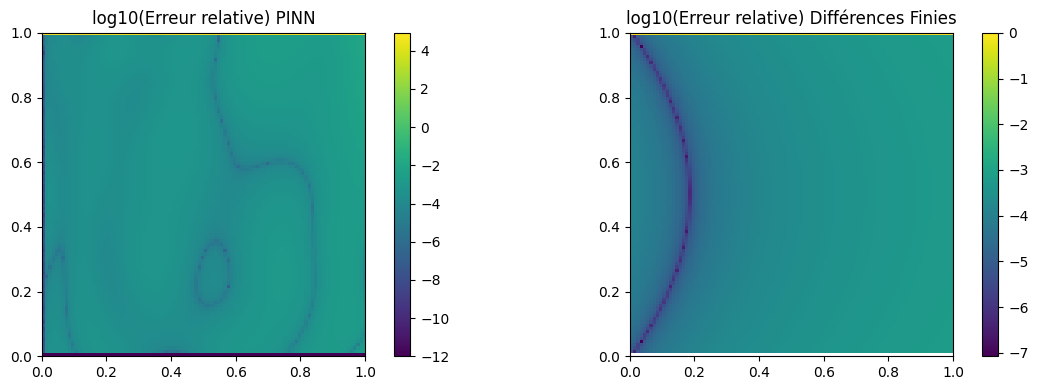

In [23]:
# --- Erreur relative en log10 ---

eps = 1e-12

# Passage en log10
err_rel_pinn_log = np.log10(err_rel_pinn + eps)
err_rel_fd_log   = np.log10(err_rel_fd + eps)

# --- Affichage ---
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# PINN
im0 = ax[0].imshow(err_rel_pinn_log, extent=[0,1,0,1], origin='lower', cmap='viridis')
ax[0].set_title("log10(Erreur relative) PINN")
plt.colorbar(im0, ax=ax[0])

# DF
im1 = ax[1].imshow(err_rel_fd_log, extent=[0,1,0,1], origin='lower', cmap='viridis')
ax[1].set_title("log10(Erreur relative) Différences Finies")
plt.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.savefig("comparaison_PINN_DF_Erreurs_Relatives_LOG10.png", dpi=300, bbox_inches='tight')
plt.show()
